# HW12 — прогноз временного ряда

Часовой ряд `target`, корректный **temporal split**, лаги/rolling/календарь, baseline **B1–B3** и **GRU (R1)**. Сравнение на validation; **test** — один раз для лучшей по val MAE модели.

In [1]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, Dataset

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True

SEED = 42


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def mape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    denom = np.clip(np.abs(y_true), 1e-8, None)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)


def metrics(y_true: np.ndarray, y_pred: np.ndarray) -> tuple[float, float, float]:
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    return mae, rmse, mape(y_true, y_pred)


try:
    ROOT = Path(__file__).resolve().parent
except NameError:
    ROOT = Path.cwd()

DATA_PATH = ROOT / "S12-hw-dataset.csv"
ART = ROOT / "artifacts"
FIG = ART / "figures"

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
FIG.mkdir(parents=True, exist_ok=True)



device: cpu


## Данные и sanity-check

Загрузка CSV, `datetime`, сортировка по времени, пропуски, график ряда.

n_obs: 4320
date range: 2025-01-01 00:00:00 — 2025-06-29 23:00:00
na per column:
 date      0
target    0
dtype: int64


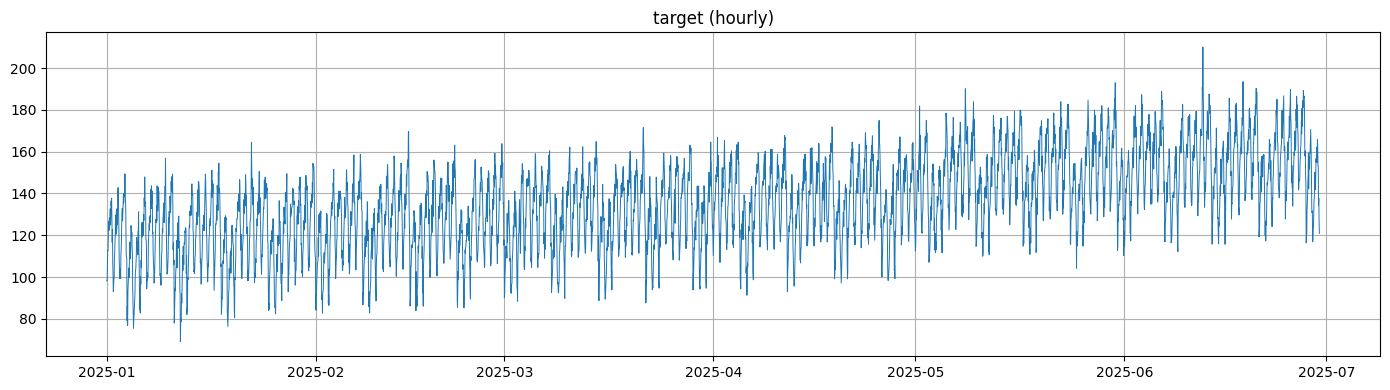

In [2]:
df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

n = len(df)
print("n_obs:", n)
print("date range:", df["date"].min(), "—", df["date"].max())
print("na per column:\n", df.isna().sum())

plt.figure(figsize=(14, 4))
plt.plot(df["date"], df["target"], linewidth=0.7)
plt.title("target (hourly)")
plt.tight_layout()
plt.show()

# Кратко: ряд похож на суточную сезонность (день/ночь) с плавными колебаниями; явных выбросов мало; стационарность не предполагаем — есть суточный паттерн.



## Temporal split

**Random split** здесь некорректен: перемешивание нарушает порядок во времени и даёт завышенную оценку (модель «видит» будущие значения ряда как соседей по выборке). Нужно **train → validation → test** по времени.

Границы: 70% / 15% / 15% наблюдений.

train indices: [0, 3024)
val indices:   [3024, 3672)
test indices:  [3672, 4320)


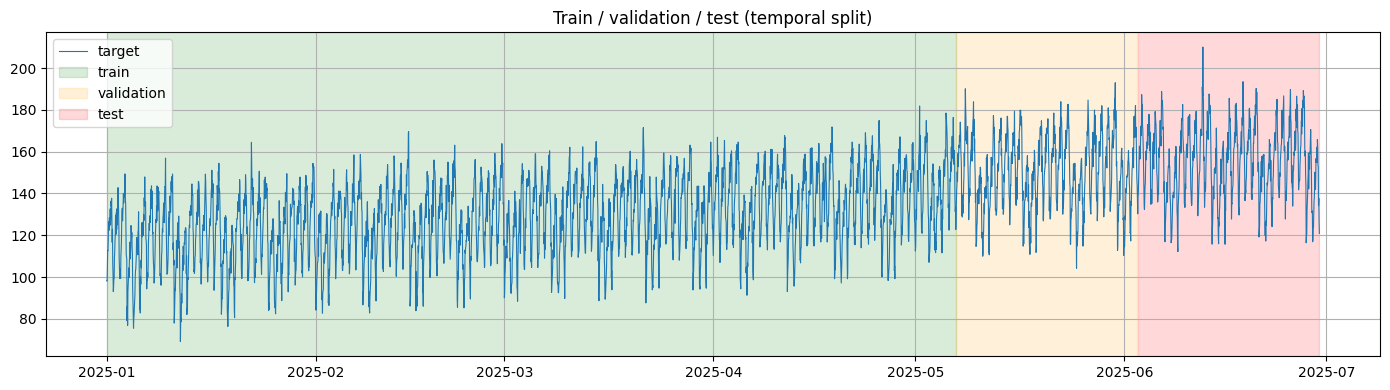

In [3]:
n_train = int(n * 0.70)
n_val = int(n * 0.15)
i_tr_end = n_train
i_va_end = n_train + n_val

y = df["target"].values.astype(np.float64)
dates = df["date"].values

print(f"train indices: [0, {i_tr_end})")
print(f"val indices:   [{i_tr_end}, {i_va_end})")
print(f"test indices:  [{i_va_end}, {n})")

plt.figure(figsize=(14, 4))
plt.plot(dates, y, label="target", color="C0", linewidth=0.8)
plt.axvspan(dates[0], dates[i_tr_end - 1], alpha=0.15, color="green", label="train")
plt.axvspan(dates[i_tr_end], dates[i_va_end - 1], alpha=0.15, color="orange", label="validation")
plt.axvspan(dates[i_va_end], dates[-1], alpha=0.15, color="red", label="test")
plt.legend(loc="upper left")
plt.title("Train / validation / test (temporal split)")
plt.tight_layout()
plt.savefig(FIG / "series_split.png", dpi=150)
plt.show()



## Признаки для B3 (без утечки из будущего)

Лаги и rolling считаются так, чтобы на шаге *t* использовать только прошлые значения (`shift(1)` после rolling). Календарь: день недели. `StandardScaler` для признаков Ridge — **fit только на train**.

In [4]:
df["lag_1"] = df["target"].shift(1)
df["lag_7"] = df["target"].shift(7)
df["lag_14"] = df["target"].shift(14)
df["rolling_mean_7"] = df["target"].rolling(7).mean().shift(1)
df["rolling_std_7"] = df["target"].rolling(7).std().shift(1)
df["dow"] = df["date"].dt.dayofweek.astype(float)

feat_cols = ["lag_1", "lag_7", "lag_14", "rolling_mean_7", "rolling_std_7", "dow"]
feat_df = df[feat_cols + ["target"]].dropna().reset_index(drop=True)
valid_idx = df[feat_cols + ["target"]].dropna().index.to_numpy()

k_ma = 24
ma = pd.Series(y).rolling(k_ma).mean().shift(1).to_numpy()

va_idx = np.arange(i_tr_end, i_va_end)
b1_val = metrics(y[va_idx], y[va_idx - 1])
b2_val = metrics(y[va_idx], ma[va_idx])

tr_f = valid_idx < i_tr_end
va_f = (valid_idx >= i_tr_end) & (valid_idx < i_va_end)
te_f = valid_idx >= i_va_end

X = feat_df[feat_cols].to_numpy()
y_f = feat_df["target"].to_numpy()
scaler_x = StandardScaler()
X_tr = scaler_x.fit_transform(X[tr_f])
ridge = Ridge(alpha=1.0, random_state=SEED)
ridge.fit(X_tr, y_f[tr_f])
X_va = scaler_x.transform(X[va_f])
X_te = scaler_x.transform(X[te_f])
pred_r_va = ridge.predict(X_va)
pred_r_te = ridge.predict(X_te)
b3_val = metrics(y_f[va_f], pred_r_va)

print("B1 val (naive-last):", b1_val)
print("B2 val (MA k=24):   ", b2_val)
print("B3 val (Ridge):     ", b3_val)



B1 val (naive-last): (6.444814814814815, 8.20102295260389, 4.39792166354992)
B2 val (MA k=24):    (13.397980324074075, 16.169903600881327, 9.198833855974383)
B3 val (Ridge):      (7.188729774210035, 8.732281856975037, 4.796688920293975)


## R1: оконное представление и GRU

`window_size=48`, масштабирование **таргета** — `StandardScaler` fit только на train-части ряда. Прогноз: следующее значение после окна.

In [5]:
window_size = 48
hidden_size = 48
batch_size = 64
lr = 1e-3
max_epochs = 80

scaler_y = StandardScaler()
scaler_y.fit(y[:i_tr_end].reshape(-1, 1))
y_s = scaler_y.transform(y.reshape(-1, 1)).flatten().astype(np.float32)


class SeqDS(Dataset):
    def __init__(self, end_indices: np.ndarray):
        self.ends = end_indices

    def __len__(self) -> int:
        return len(self.ends)

    def __getitem__(self, i: int):
        e = int(self.ends[i])
        x = y_s[e - window_size : e]
        return torch.from_numpy(x).unsqueeze(-1), torch.tensor(y_s[e], dtype=torch.float32)


train_ends = np.arange(window_size, i_tr_end, dtype=np.int64)
val_ends = np.arange(i_tr_end, i_va_end, dtype=np.int64)

train_loader = DataLoader(SeqDS(train_ends), batch_size=batch_size, shuffle=True, drop_last=False)
val_loader = DataLoader(SeqDS(val_ends), batch_size=batch_size, shuffle=False)


class GRUForecast(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.gru = nn.GRU(1, hidden_size, num_layers=1, batch_first=True)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.gru(x)
        return self.head(out[:, -1, :]).squeeze(-1)


model = GRUForecast().to(device)
opt = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = nn.MSELoss()

best_val_mae_gru = float("inf")
best_state = None
hist_train_loss: list[float] = []
hist_val_mae: list[float] = []


@torch.no_grad()
def eval_loader(loader: DataLoader) -> tuple[float, float, float]:
    model.eval()
    preds, acts = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        pr = model(xb).cpu().numpy()
        preds.append(pr)
        acts.append(yb.numpy())
    p = np.concatenate(preds)
    a = np.concatenate(acts)
    p_orig = scaler_y.inverse_transform(p.reshape(-1, 1)).flatten()
    a_orig = scaler_y.inverse_transform(a.reshape(-1, 1)).flatten()
    return metrics(a_orig, p_orig)


for _ in range(max_epochs):
    model.train()
    losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        opt.step()
        losses.append(float(loss.item()))
    hist_train_loss.append(float(np.mean(losses)) if losses else 0.0)
    vmae, _, _ = eval_loader(val_loader)
    hist_val_mae.append(vmae)
    if vmae < best_val_mae_gru:
        best_val_mae_gru = vmae
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

assert best_state is not None
model.load_state_dict(best_state)
r1_val = eval_loader(val_loader)
print("R1 val (GRU, best checkpoint):", r1_val)



R1 val (GRU, best checkpoint): (4.927534103393555, 6.459128480589294, 3.3420166969299316)


## Выбор лучшей модели по validation и один проход test

In [6]:
results_val = {"B1": b1_val, "B2": b2_val, "B3": b3_val, "R1": r1_val}
best_id = min(results_val, key=lambda k: results_val[k][0])

test_metrics_by_id: dict[str, tuple[float, float, float] | None] = {
    "B1": None,
    "B2": None,
    "B3": None,
    "R1": None,
}
te_idx = np.arange(i_va_end, n)
if best_id == "B1":
    test_metrics_by_id["B1"] = metrics(y[te_idx], y[te_idx - 1])
elif best_id == "B2":
    test_metrics_by_id["B2"] = metrics(y[te_idx], ma[te_idx])
elif best_id == "B3":
    test_metrics_by_id["B3"] = metrics(y_f[te_f], pred_r_te)
else:
    test_ends = np.arange(i_va_end, n, dtype=np.int64)
    test_loader = DataLoader(SeqDS(test_ends), batch_size=batch_size, shuffle=False)
    test_metrics_by_id["R1"] = eval_loader(test_loader)

test_ends = np.arange(i_va_end, n, dtype=np.int64)
split_summary = f"train[0:{i_tr_end}), val[{i_tr_end}:{i_va_end}), test[{i_va_end}:{n})"

print("best by val MAE:", best_id)
print("test metrics (winner only):", {k: v for k, v in test_metrics_by_id.items() if v})



best by val MAE: R1
test metrics (winner only): {'R1': (5.400492191314697, 6.957158185517312, 3.503037214279175)}


## Графики и артефакты

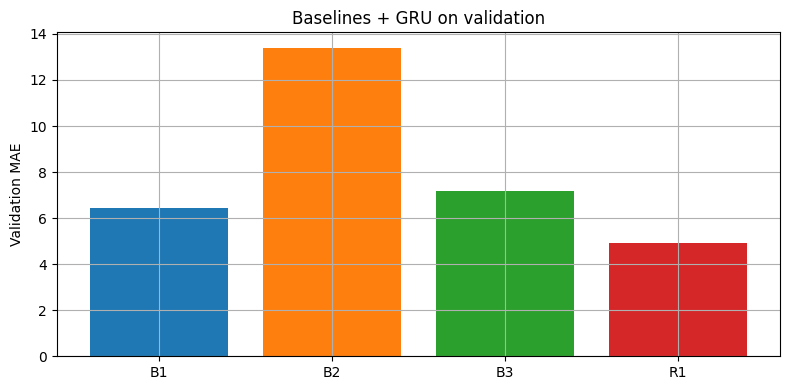

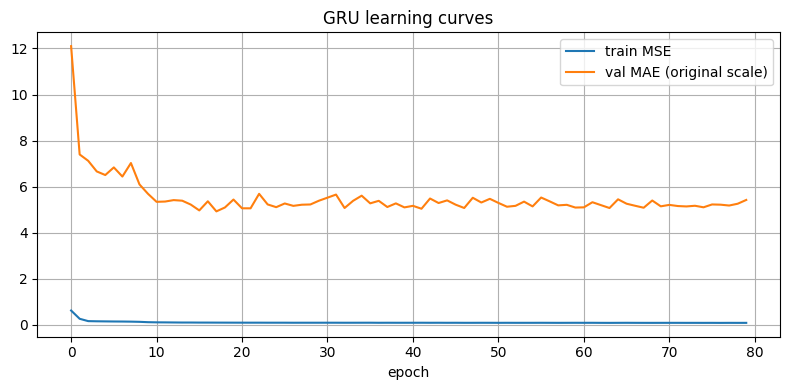

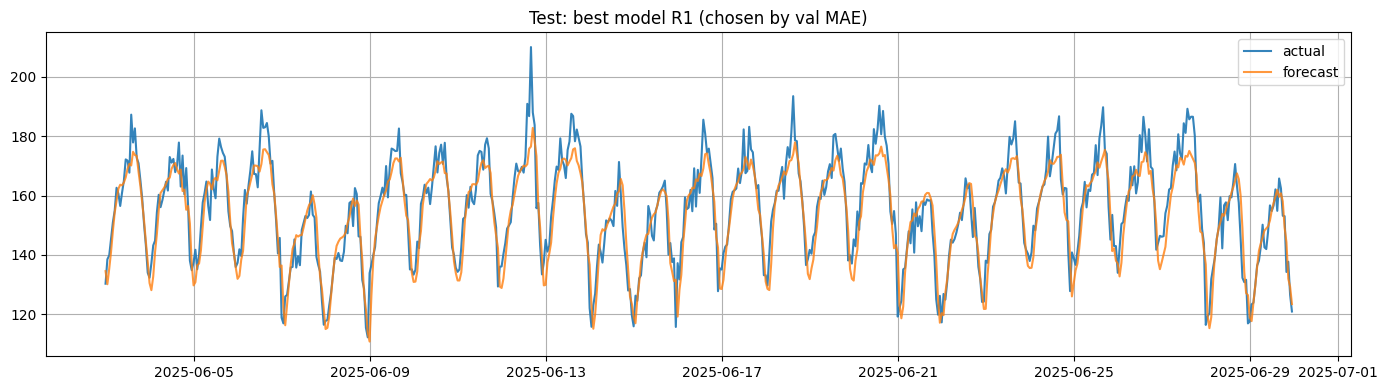

Saved artifacts under c:\Users\igork\OneDrive\Рабочий стол\ИНЖ ИИ\homeworks\HW12\artifacts


In [7]:
names = ["B1", "B2", "B3", "R1"]
plt.figure(figsize=(8, 4))
plt.bar(names, [results_val[k][0] for k in names], color=["C0", "C1", "C2", "C3"])
plt.ylabel("Validation MAE")
plt.title("Baselines + GRU on validation")
plt.tight_layout()
plt.savefig(FIG / "baselines_compare.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(hist_train_loss, label="train MSE")
plt.plot(hist_val_mae, label="val MAE (original scale)")
plt.xlabel("epoch")
plt.legend()
plt.title("GRU learning curves")
plt.tight_layout()
plt.savefig(FIG / "gru_learning_curves.png", dpi=150)
plt.show()

plt.figure(figsize=(14, 4))
if best_id == "B1":
    pred_te = y[te_idx - 1]
    plt.plot(df.loc[te_idx, "date"], y[te_idx], label="actual", alpha=0.9)
    plt.plot(df.loc[te_idx, "date"], pred_te, label="forecast", alpha=0.8)
elif best_id == "B2":
    pred_te = ma[te_idx]
    plt.plot(df.loc[te_idx, "date"], y[te_idx], label="actual", alpha=0.9)
    plt.plot(df.loc[te_idx, "date"], pred_te, label="forecast", alpha=0.8)
elif best_id == "B3":
    pred_te = pred_r_te
    idx_b3 = valid_idx[te_f]
    plt.plot(df.loc[idx_b3, "date"], y_f[te_f], label="actual", alpha=0.9)
    plt.plot(df.loc[idx_b3, "date"], pred_te, label="forecast", alpha=0.8)
else:
    model.eval()
    preds: list[float] = []
    with torch.no_grad():
        for e in test_ends:
            e = int(e)
            x = torch.from_numpy(y_s[e - window_size : e]).unsqueeze(0).unsqueeze(-1).to(device)
            pr = model(x).cpu().item()
            preds.append(pr)
    pred_te = scaler_y.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()
    plt.plot(df.loc[test_ends, "date"], y[test_ends], label="actual", alpha=0.9)
    plt.plot(df.loc[test_ends, "date"], pred_te, label="forecast", alpha=0.8)
plt.legend()
plt.title(f"Test: best model {best_id} (chosen by val MAE)")
plt.tight_layout()
plt.savefig(FIG / "best_forecast_test.png", dpi=150)
plt.show()

torch.save(best_state, ART / "best_gru.pt")
cfg = {
    "seed": SEED,
    "window_size": window_size,
    "hidden_size": hidden_size,
    "num_layers": 1,
    "batch_size": batch_size,
    "lr": lr,
    "max_epochs": max_epochs,
    "optimizer": "Adam",
    "scaler_y": "StandardScaler on train target only",
    "device": str(device),
    "best_val_mae_gru": best_val_mae_gru,
    "dataset": "S12-hw-dataset.csv",
}
(ART / "best_gru_config.json").write_text(json.dumps(cfg, indent=2), encoding="utf-8")

rows = []
for eid in names:
    vm = results_val[eid]
    tm = test_metrics_by_id[eid]
    rows.append(
        {
            "experiment_id": eid,
            "task": "forecasting",
            "dataset": "S12-hw-dataset.csv",
            "seed": SEED,
            "split_summary": split_summary,
            "window_size": window_size if eid == "R1" else "",
            "horizon": 1,
            "model_summary": {
                "B1": "naive-last",
                "B2": f"moving-average k={k_ma}",
                "B3": "Ridge(alpha=1)",
                "R1": "GRU(1->48->1)",
            }[eid],
            "features_summary": "lags 1,7,14 + roll mean/std 7 + dow" if eid == "B3" else "univariate history",
            "scaler": "StandardScaler on train (B3 features; R1 target)" if eid in ("B3", "R1") else "",
            "optimizer": "Adam" if eid == "R1" else "",
            "lr": lr if eid == "R1" else "",
            "epochs_trained": max_epochs if eid == "R1" else "",
            "best_val_mae": vm[0],
            "best_val_rmse": vm[1],
            "best_val_mape": vm[2],
            "test_mae": tm[0] if tm else "",
            "test_rmse": tm[1] if tm else "",
            "test_mape": tm[2] if tm else "",
            "notes": "overall best by val MAE: " + best_id,
        }
    )
pd.DataFrame(rows).to_csv(ART / "runs.csv", index=False)
print("Saved artifacts under", ART)

